# yolo11-nano 사용한 전이학습 ROI 코랩 마스터 코드


### : 2개의 모델을 사용한 단계별 필터링 (ROI) 방식


### * 주의) 모델1, 2에 대해 각각 전이학습 진행 (즉 모델2인 yolo pose 모델에 대해서 키포인트 라벨링한 데이터셋으로 전이학습 진행!)

# 0단계: 환경 설정 및 라이브러리 설치

### 라이브러리 설치

In [ ]:
# 1. 라이브러리 설치 (가장 먼저 실행)
!pip install ultralytics
""
# 설치 확인을 위한 체크
import ultralytics
ultralytics.checks()


Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.3/107.7 GB disk)


In [ ]:
import os
import json
import cv2
import shutil
import numpy as np
from google.colab import drive, files
from ultralytics import YOLO
import matplotlib.pyplot as plt

### 구글 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Mounted at /content/drive
g-drive mounted.


# 1단계 : 데이터 정제 (YOLOv11 변환 및 학습 준비)


- 로보플로우에서 키포인트 라벨링한 데이터셋을 coco 포맷인 json으로 다운로드

- 다운로드한 json 파일을 yolo 학습을 위한 txt파일로 변환

* 이때 주의할 점 : 순수 바운딩 박스 Object Detection 변환


-> 변환 : 키포인트를 제거하려 바운딩 박스 정보만 남김

### 1-1) 모델1에 대한 전이학습을 위한 데이터셋 1 정제

->  yolo11-nano 모델 전이학습에 사용할 3가지 클래스(fire, person, weapon)에 대한 바운딩박스 라벨링 coco 데이터를 yolo txt 라벨링 데이터로 변환

-> 개선 : 로보플로우에서 yolo11v 내려받기 타입으로 선택하고 데이터셋 다운로드!

In [ ]:
# import os, zipfile, json, shutil, random
# from google.colab import drive

# # drive.mount('/content/drive')


# # 설정
# ZIP_FILE = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_bbox_aug_450_1774_v2.coco.zip'
# EXTRACT_DIR = '/content/dataset1_raw'
# SAVE_DIR = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_Final_bbox_aug_450_1774_v2.zip'
# TEMP_DIR = '/content/temp_dataset1'
# FINAL_DIR = '/content/final_dataset1'



# # 클래스 매핑 (JSON ID: 1,2,3 -> YOLO ID: 0,1,2로 변경)
# # 본인의 JSON category id를 확인해서 넣으세요!
# id_map = {1: 0, 2: 1, 3: 2}



# # 1. 압축 해제
# if os.path.exists(EXTRACT_DIR): shutil.rmtree(EXTRACT_DIR)
# with zipfile.ZipFile(ZIP_FILE, 'r') as z: z.extractall(EXTRACT_DIR)



# # 2. 정제 (기존 파일 싹 삭제 후 새로 생성)
# if os.path.exists(TEMP_DIR): shutil.rmtree(TEMP_DIR)
# os.makedirs(f"{TEMP_DIR}/images", exist_ok=True)
# os.makedirs(f"{TEMP_DIR}/labels", exist_ok=True)

# def convert_det_fresh(coco_json, img_dir):
#     with open(coco_json, 'r') as f: data = json.load(f)
#     imgs = {i['id']: i for i in data['images']}

#     # 이미지 복사
#     for img_info in data['images']:
#         shutil.copy(os.path.join(img_dir, img_info['file_name']), f"{TEMP_DIR}/images/")

#     # 라벨 생성 ('w' 모드로 열어서 이전 내용 초기화!)
#     for ann in data['annotations']:
#         img = imgs[ann['image_id']]
#         cls_id = id_map.get(ann['category_id'], None)

#         # 유효하지 않은 클래스 ID면 건너뜀
#         if cls_id is None: continue

#         x, y, w, h = ann['bbox']
#         xc, yc = (x + w/2)/img['width'], (y + h/2)/img['height']
#         wn, hn = w/img['width'], h/img['height']

#         # 'a' 대신 'a'로 하되, 각 파일별로 처음에 한 번만 초기화하는 로직 필요
#         # 간단하게: 파일이 있으면 append, 없으면 write
#         label_file = os.path.join(TEMP_DIR, "labels", os.path.splitext(img['file_name'])[0] + ".txt")
#         with open(label_file, 'a') as f:
#             f.write(f"{cls_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}\n")

# for s in ['train', 'valid', 'test']:
#     if os.path.exists(f'{EXTRACT_DIR}/{s}/_annotations.coco.json'):
#         convert_det_fresh(f'{EXTRACT_DIR}/{s}/_annotations.coco.json', f'{EXTRACT_DIR}/{s}')



# # 3. 7:2:1 재분할
# all_imgs = [f for f in os.listdir(f"{TEMP_DIR}/images") if f.endswith(('.jpg', '.png'))]
# random.shuffle(all_imgs)
# splits = {'train': all_imgs[:int(len(all_imgs)*0.7)], 'valid': all_imgs[int(len(all_imgs)*0.7):int(len(all_imgs)*0.9)], 'test': all_imgs[int(len(all_imgs)*0.9):]}

# for s, imgs in splits.items():
#     os.makedirs(f"{FINAL_DIR}/{s}/images", exist_ok=True); os.makedirs(f"{FINAL_DIR}/{s}/labels", exist_ok=True)
#     for i in imgs:
#         shutil.copy(f"{TEMP_DIR}/images/{i}", f"{FINAL_DIR}/{s}/images/")
#         if os.path.exists(f"{TEMP_DIR}/labels/{os.path.splitext(i)[0]}.txt"):
#             shutil.copy(f"{TEMP_DIR}/labels/{os.path.splitext(i)[0]}.txt", f"{FINAL_DIR}/{s}/labels/")



# # 4. 경로 꼬임 없는 압축
# os.chdir(FINAL_DIR)
# with zipfile.ZipFile(SAVE_DIR, 'w', zipfile.ZIP_DEFLATED) as zipf:
#     for root, dirs, files in os.walk('.'):
#         for file in files:
#             zipf.write(os.path.join(root, file))
# os.chdir('/content')
# print("데이터셋 1 완료!")







데이터셋 1 완료!


### 1-2) 모델 2에 대한 전이학습을 위한 데이터셋 2 정제
* yolo11-nano-pose 모델 전이학습에 사용할 1가지 클래스(person)에 대한 키포인트 라벨링 coco 데이터를 yolo txt 라벨링 데이터로 변환

In [ ]:
# 키포인트 유실되는 경우, 키포인트 데이터 비어두는게 아니라! 0으로 패딩 및 visibility 처리하기
# 0 : 해당 키포인트가 프레임 밖을 벗어남
# 1 : 해당 키포인트가 프레임 안에 가려짐
# 2 : 해당 키포인트가 프레임 안에 보임



import os, json, shutil, zipfile, yaml
from google.colab import drive

# 1. 드라이브 마운트
# drive.mount('/content/drive')



# 2. 경로 설정
ZIP_FILE = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_keypoint_aug_150_570_v2.coco.zip'
DRIVE_SAVE_ZIP = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_FINAL_keypoint_aug_150_570_v2.zip'
EXTRACT_PATH = '/content/raw_coco_data'
FINAL_DATASET_PATH = '/content/final_pose_dataset'

# 3. 초기화
if os.path.exists(EXTRACT_PATH): shutil.rmtree(EXTRACT_PATH)
if os.path.exists(FINAL_DATASET_PATH): shutil.rmtree(FINAL_DATASET_PATH)

# 4. 압축 해제
with zipfile.ZipFile(ZIP_FILE, 'r') as z: z.extractall(EXTRACT_PATH)

# 5. 키포인트 보존 및 Visibility 고려 변환 함수
def convert_coco_to_yolo_pose(json_path, images_source_dir, split_name):
    labels_dir = os.path.join(FINAL_DATASET_PATH, split_name, 'labels')
    images_dir = os.path.join(FINAL_DATASET_PATH, split_name, 'images')
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(images_dir, exist_ok=True)

    with open(json_path, 'r') as f:
        data = json.load(f)

    # 클래스 매핑: person을 0번으로 강제 설정
    cat_map = {}
    for cat in data['categories']:
        if cat['name'] == 'person': cat_map[cat['id']] = 0
        elif cat['name'] == 'fire': cat_map[cat['id']] = 1
        else: cat_map[cat['id']] = 2

    for ann in data['annotations']:
        img_id = ann['image_id']
        img_info = next(i for i in data['images'] if i['id'] == img_id)

        # 박스 정규화
        x_c = (ann['bbox'][0] + ann['bbox'][2]/2) / img_info['width']
        y_c = (ann['bbox'][1] + ann['bbox'][3]/2) / img_info['height']
        w_n = ann['bbox'][2] / img_info['width']
        h_n = ann['bbox'][3] / img_info['height']

        # 키포인트 정규화 (x, y, v)
        kpts = ann['keypoints']
        normalized_kpts = []

        # 11개 키포인트 강제 순회 (COCO 데이터셋 기준)
        for i in range(11):
            idx = i * 3
            if idx + 2 < len(kpts):
                vx = kpts[idx] / img_info['width']
                vy = kpts[idx+1] / img_info['height']
                v_val = kpts[idx+2] # 0, 1, 2

                # [핵심] v=0이면 좌표도 0으로 처리하여 모델이 무시하도록 함
                if v_val == 0:
                    normalized_kpts.extend(["0.000000", "0.000000", "0"])
                else:
                    normalized_kpts.extend([f"{vx:.6f}", f"{vy:.6f}", str(int(v_val))])
            else:
                # 데이터가 없는 경우도 v=0 처리
                normalized_kpts.extend(["0.000000", "0.000000", "0"])

        line = f"{cat_map[ann['category_id']]} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f} " + " ".join(normalized_kpts)

        txt_path = os.path.join(labels_dir, os.path.splitext(img_info['file_name'])[0] + '.txt')
        with open(txt_path, 'a') as f: f.write(line + '\n')

    # 이미지 복사
    for img in data['images']:
        src = os.path.join(images_source_dir, img['file_name'])
        if os.path.exists(src):
            shutil.copy(src, os.path.join(images_dir, img['file_name']))

# 6. 실행
for split in ['train', 'valid', 'test']:
    j_path = os.path.join(EXTRACT_PATH, split, '_annotations.coco.json')
    if os.path.exists(j_path):
        convert_coco_to_yolo_pose(j_path, os.path.join(EXTRACT_PATH, split), split)



# 7. YAML 저장 (kpt_shape 명시)
yaml_content = {
    'path': '/content/dataset',
    'train': 'train/images', 'val': 'valid/images', 'test': 'test/images',
    'names': {0: 'person', 1: 'fire', 2: 'weapon'},
    'kpt_shape': [11, 3]
}
with open(os.path.join(FINAL_DATASET_PATH, 'data.yaml'), 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)


# 8. 드라이브 백업
print(f"📦 압축 시작: {DRIVE_SAVE_ZIP}")
with zipfile.ZipFile(DRIVE_SAVE_ZIP, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(FINAL_DATASET_PATH):
        for file in files:
            full_path = os.path.join(root, file)
            zipf.write(full_path, os.path.relpath(full_path, FINAL_DATASET_PATH))


print(f"✅ 완료! 키포인트(v=0,1,2 보존) 및 person=0 클래스 정제 완료.")










📦 압축 시작: /content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_POSE_keypoint_aug_150_570_v2.zip
✅ 완료! 키포인트(v=0,1,2 보존) 및 person=0 클래스 정제 완료.


# 2단계 : 학습

-> 초기 모델의 베이스 모델 생성

* YAML 생성 및 YOLO26-nano post 모델 사용한 전이 학습을 통한 베이스 모델 생성

### (참고) 코랩 세션 유지용 코드

In [ ]:
# -------------------------------
# (참고) 세션 유지용 코드
# -> 코랩을 통한 모델 학습 중 세션이 끊기는 걸 방지하기 위해 '저장'과 같은 행동 반복
# -> 학습이 길어지면 코랩이 끊길 수 있습니다.
# -> 크롬 브라우저에서 F12를 눌러 콘솔(Console) 창에 아래 코드를 붙여넣고 엔터를 치면 연결이 유지됩니다.


# -------------------------------
# 1단계: (크롬 기준) 도구 더보기 -> 개발자 도구 -> console -> 아래 명령어 직접 입력!!!! (복붙 ㄴㄴ)
allow pasting


# 2단계: 아래 코드 복붙
# -> 아래 코드는3초에 한번씩 자동저장하면서 세션 유지하려는 코드...

setInterval(() => {
  console.log("세션 유지 중...");
  window.scrollTo(0, document.body.scrollHeight);
  window.scrollTo(0, 0);
}, 30000);



### data.yaml 생성

* 욜로에서 학습에 사용하는 파일, 학습 데이터셋 경로 및 클래스 정보 및 키포인트 정보가 명시되어있다.


In [ ]:
yaml_path = os.path.join(final_dataset_path, 'custom_data.yaml')

yaml_content = f"""
path: {final_dataset_path}
train: train/images
val: valid/images
test: test/images
names:
  0: fire
  1: person
  2: weapon
"""

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

# 학습1) yolo11-nano 모델을 사용한 전이학습

* 3가지 클래스(fire, person, weapon)에 대한 바운딩박스 라벨 데이터셋을 사용해 전이학습

In [ ]:

import os, zipfile, shutil, yaml
from ultralytics import YOLO
from google.colab import drive

# drive.mount('/content/drive')

# 설정
ZIP_FILE = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_Final_bbox_aug_450_1774_v2.zip'
EXTRACT_PATH = '/content/dataset1_backup'
BACKUP_ZIP = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1.zip'
BACKUP_PATH = '/content/model1_backup'

# 1. 압축 해제 (데이터셋 & 모델)
os.makedirs(EXTRACT_PATH, exist_ok=True)
with zipfile.ZipFile(ZIP_FILE, 'r') as z: z.extractall(EXTRACT_PATH)
with zipfile.ZipFile(BACKUP_ZIP, 'r') as z: z.extractall(BACKUP_PATH)

# 2. YAML 파일 생성 (데이터셋 경로 및 클래스 설정)
data_config = {
    'path': EXTRACT_PATH,
    'train': 'train/images',
    'val': 'valid/images',
    'names': {0: 'fire', 1: 'person', 2: 'weapon'}
}
with open(f'{EXTRACT_PATH}/data.yaml', 'w') as f:
    yaml.dump(data_config, f)

# 3. 전이학습
model = YOLO(os.path.join(BACKUP_PATH, 'best.pt'))
model.train(
    data=f'{EXTRACT_PATH}/data.yaml',
    epochs=50,
    imgsz=640,
    lr0=0.001,      # 수동 조절 가능
    optimizer='AdamW'
)

# 4. 가중치만 저장
shutil.copy('/content/runs/detect/train/weights/best.pt', '/content/drive/MyDrive/model1_final_best.pt')
print("모델 1 학습 완료!")







# 학습2) yolo11-nano-pose 모델을 사용한 전이학습

* 1가지 클래스(person)에 대한 키포인트 라벨 데이터셋을 사용해 전이학습

### 코랩 세션이 유지된 상태 즉 데이터 정제 완료되어 코랩 세션에 저장된 최종 데이터셋2를 사용한 전이학습

In [ ]:
import os
import yaml
import glob
import zipfile
from ultralytics import YOLO
from google.colab import drive



# 1. 드라이브 마운트
# drive.mount('/content/drive')



# 2. 경로 설정
DATASET_PATH = '/content/final_pose_dataset'
YAML_PATH = os.path.join(DATASET_PATH, 'data.yaml')
DRIVE_SAVE_PATH = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2/[Tracking_Robot]_roi_model2_transfer_YOLO11-pose_PT_v_2.zip'

# 3. [핵심] YAML 파일 강제 재생성 (경로 정렬)
# 학습 전에 YAML 파일을 현재 환경에 맞는 절대 경로로 덮어씁니다.
data_config = {
    'path': DATASET_PATH,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'names': {0: 'person'},
    'kpt_shape': [11, 3]
}

with open(YAML_PATH, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)
print(f"✅ YAML 파일 재설정 완료 (경로: {DATASET_PATH})")

# 4. 모델 학습 실행
model = YOLO('yolo11n-pose.pt')

print("🚀 학습 시작...")
model.train(
    data=YAML_PATH,
    epochs=50,
    imgsz=640,
    lr0=0.001,
    optimizer='AdamW',
    batch=16,
    device=0
)

# 5. 결과물만 깔끔하게 압축 저장
list_of_train_dirs = glob.glob('/content/runs/pose/train*')
if list_of_train_dirs:
    latest_train_dir = max(list_of_train_dirs, key=os.path.getctime)
    print(f"📦 학습 결과 폴더 감지: {latest_train_dir}")

    print(f"📦 결과물을 드라이브에 저장 중: {DRIVE_SAVE_PATH}")

    with zipfile.ZipFile(DRIVE_SAVE_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(latest_train_dir):
            for file in files:
                full_path = os.path.join(root, file)
                # 폴더 구조 제거하고 파일만 압축
                relative_path = os.path.relpath(full_path, latest_train_dir)
                zipf.write(full_path, arcname=relative_path)

    print("✅ 모델 학습 결과물 백업 완료!")
else:
    print("❌ 학습 결과 폴더를 찾을 수 없습니다.")



✅ YAML 파일 재설정 완료 (경로: /content/final_pose_dataset)
🚀 학습 시작...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_pose_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, o

### 아래는 코랩 세션이 끊어졌을 때... 백업 데이터셋2를 불러와서 압축 해제 후 학습에 사용...

In [ ]:
import os, zipfile, yaml
from ultralytics import YOLO
from google.colab import drive

# 1. 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 및 설정
ZIP_FILE = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_FINAL_keypoint_aug_150_570_v2.zip'
EXTRACT_PATH = '/content/dataset2' # 압축을 풀 폴더
DRIVE_SAVE_PATH = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2/[Tracking_Robot]_roi_model2_YOLO11-pose_PT_v_2.zip'

# 3. 데이터셋 압축 해제
if os.path.exists(EXTRACT_PATH):
    import shutil
    shutil.rmtree(EXTRACT_PATH)
os.makedirs(EXTRACT_PATH, exist_ok=True)

print(f"📦 압축 해제 중: {ZIP_FILE}")
with zipfile.ZipFile(ZIP_FILE, 'r') as z:
    z.extractall(EXTRACT_PATH)

# 4. YAML 파일 생성 (경로 주의)
# YOLO는 'path'를 기준으로 train/val 폴더를 찾습니다.
data_config = {
    'path': EXTRACT_PATH,  # 데이터셋 루트 디렉토리
    'train': 'train/images', # 'path' + 'train' 이 실제 이미지 폴더 경로여야 함
    'val': 'valid/images',
    'names': {0: 'person'},
    'kpt_shape': [11, 3]    # 11개 키포인트, 3값(x, y, v)
}

yaml_path = os.path.join(EXTRACT_PATH, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)
print(f"✅ YAML 파일 생성 완료: {yaml_path}")

# 5. 전이학습 (YOLO11 Pose)
model = YOLO('yolo11n-pose.pt')

# 학습 수행
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    lr0=0.001,
    optimizer='AdamW',
    batch=16, # 메모리 상황에 따라 조절 (기본값 16)
    device=0  # GPU 사용
)

# 6. 학습 결과 압축 및 드라이브 저장
# 학습이 끝나면 보통 /content/runs/pose/train/ 에 결과가 저장됩니다.
TRAIN_RESULT_PATH = '/content/runs/pose/train'

if os.path.exists(TRAIN_RESULT_PATH):
    print(f"📦 학습 결과를 압축하여 저장 중: {DRIVE_SAVE_PATH}")
    with zipfile.ZipFile(DRIVE_SAVE_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(TRAIN_RESULT_PATH):
            for file in files:
                file_path = os.path.join(root, file)
                # 상대 경로로 저장해야 나중에 압축 풀 때 폴더 구조가 유지됨
                zipf.write(file_path, os.path.relpath(file_path, TRAIN_RESULT_PATH))
    print("✅ 완료!")
else:
    print("❌ 학습 결과 경로를 찾을 수 없습니다.")

In [ ]:
# import os, zipfile, shutil, yaml
# from ultralytics import YOLO
# from google.colab import drive

# # drive.mount('/content/drive')

# # 설정
# ZIP_FILE = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_FINAL_keypoint_aug_150_570_v2.zip'
# EXTRACT_PATH = '/content/dataset2_backup'

# # 1. 압축 해제
# os.makedirs(EXTRACT_PATH, exist_ok=True)
# with zipfile.ZipFile(ZIP_FILE, 'r') as z: z.extractall(EXTRACT_PATH)


# # 학습 결과가 저장되는 경로
# TRAIN_RESULT_PATH = '/content/runs/pose/train'
# # 드라이브에 저장할 압축 파일 경로
# DRIVE_SAVE_PATH = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2/[Tracking_Robot]_roi_model2_YOLO11-pose_PT_v_2.zip'



# # 1. 압축 해제
# os.makedirs(EXTRACT_PATH, exist_ok=True)
# with zipfile.ZipFile(ZIP_FILE, 'r') as z: z.extractall(EXTRACT_PATH)



# # 2. YAML 파일 생성
# data_config = {
#     'path': EXTRACT_PATH,
#     'train': 'train/images',
#     'val': 'valid/images',
#     'names': {0: 'person'},
#     'kpt_shape': [11, 3]
# }
# with open(f'{EXTRACT_PATH}/data.yaml', 'w') as f:
#     yaml.dump(data_config, f)



# # 3. 전이학습
# model = YOLO('yolo11n-pose.pt')
# model.train(
#     data=f'{EXTRACT_PATH}/data.yaml',
#     epochs=50,
#     imgsz=640,
#     lr0=0.001,
#     optimizer='AdamW'
# )

# # 4. [수정됨] 학습 결과 폴더 전체를 경로 꼬임 없이 압축하여 저장
# print("학습 결과를 압축하여 드라이브에 저장 중...")
# os.chdir(TRAIN_RESULT_PATH) # 결과 폴더로 이동

# with zipfile.ZipFile(DRIVE_SAVE_PATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
#     for root, dirs, files in os.walk('.'):
#         for file in files:
#             zipf.write(os.path.join(root, file))


# os.chdir('/content') # 원래 경로로 복귀
# print(f"모델 2 학습 완료 및 결과 압축 저장 성공: {DRIVE_SAVE_PATH}")



Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset2_backup/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, p

### YOLO11-nano 모델을 사용한 전이 학습

* 학습 ㄱㄱ

In [ ]:
# YOLO26-nano 모델을 사용한 전이 학습
# -> 주의: 키포인트가 아닌! 바운딩 박스 학습할 것이므로 일반 나노 모델 사용!


# ⭐ [실험 가이드] YOLO11 또는 YOLO26 실험 시 모델 파일명만 바꾸면 동작합니다!
# Case 1) YOLO11 미세조정 테스트 시: YOLO('yolo11n.pt')
# Case 2) YOLO26 미세조정 테스트 시: YOLO('yolo26n.pt')
# 💡 [A/B 교차 벤치마킹 분석을 위한 핵심 스위칭 라인]

model = YOLO('yolo11n.pt')

model.train(
    data=yaml_path,
    epochs=50,             # 3일 마감 속도전을 위해 에포크 최적화 (필요시 100 조정)
    imgsz=320,             # 💡 [라즈베리파이 CPU 가속화 최적화] 640 해상도 대비 연산 픽셀 수가 4배 감소하여 학습 및 추론 속도가 극대화됨
    batch=32,              # 해상도가 줄었으므로 배치 사이즈를 늘려 학습 안정성 확보
    project='/content/project/runs',
    name='YOLO_Detection_Final'
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/project/[Tracking_Robot]_dataset_YOLO_Final_bbox_aug_1330_v1/custom_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO_Detection_Final-2, nbs=64, nms=False, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b2833f72300>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

* 학습 모델 저장 : 폴더 자체를 압축해 구글 드라이브에 저장

In [ ]:
# 학습 모델 저장




# 2. 경로 설정
# model.trainer.save_dir은 실제 학습 결과가 저장된 경로를 가지고 있습니다. (예: /content/project/runs/YOLO_Detection_Final)
actual_run_path = model.trainer.save_dir
new_model_name = "[Tracking_Robot]_model_YOLO11_ROI_PT_v_1"
temp_rename_path = f"/content/{new_model_name}"
drive_save_path = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1'


# 구글 드라이브 폴더가 없으면 생성
os.makedirs(drive_save_path, exist_ok=True)

print(f"📦 학습 완료 폴더: {actual_run_path}")



# 3. 폴더 이름 변경 및 백업 작업
# 기존에 동일한 이름의 임시 폴더가 있다면 삭제
if os.path.exists(temp_rename_path):
    shutil.rmtree(temp_rename_path)

# (1) 학습 결과 폴더를 원하는 이름으로 임시 복사/이동
shutil.copytree(actual_run_path, temp_rename_path)

# (2) 압축 파일 생성 (내용물만 깔끔하게 압축하기 위해 -j 대신 폴더 진입 후 압축)
backup_zip_path = os.path.join(drive_save_path, f"{new_model_name}.zip")

# !cd를 이용해 해당 폴더로 이동 후 압축하여 상위 경로 구조를 제거함
!cd /content && zip -r -q "{backup_zip_path}" "{new_model_name}"

print(f"✅ 구글 드라이브에 모델 백업 완료: {backup_zip_path}")




# (선택 사항) 압축하지 않은 폴더 자체도 드라이브에 담고 싶다면 아래 주석 해제
# final_drive_folder = os.path.join(drive_save_path, new_model_name)
# if os.path.exists(final_drive_folder): shutil.rmtree(final_drive_folder)
# shutil.copytree(temp_rename_path, final_drive_folder)
# print(f"✅ 폴더 복사 완료: {final_drive_folder}")




📦 학습 완료 폴더: /content/project/runs/YOLO_Detection_Final-2
✅ 구글 드라이브에 모델 백업 완료: /content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1.zip


### 베이스 모델 성능 평가


->  욜로 포즈 모델 학습 후 만들어지는 기본적인 성능 평가 자료 외 추가 자료 생성


->  추가 자료 :


* 모델 물리적 사양 측정 (TFLite 비교용 필수 데이터 - 나중에 tflite로 변환한 3가지 모델과의 성능 비교용)


* 정밀 추론 속도(Latency) 측정 (라즈베리 파이 5 시뮬레이션 - 가상의 이미지를 만들고 그 이미지에 대한 추론 속도 측정)


* CSV 로그 분석 (전체 학습 과정 요약)


* 통합 시각화 리포트 생성 및 저장 (PNG)

# 3단계-1 : 1번 모델(YOLO11n-BBox) 단독 성능 평가 파트

* 모델 성능 평가 데이터 저장 및 시각화

* 시각화 : 성능지표(mAP, Confusion Matrix)

### 코랩 세션이 끊길 때, 성능 평가 방법

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


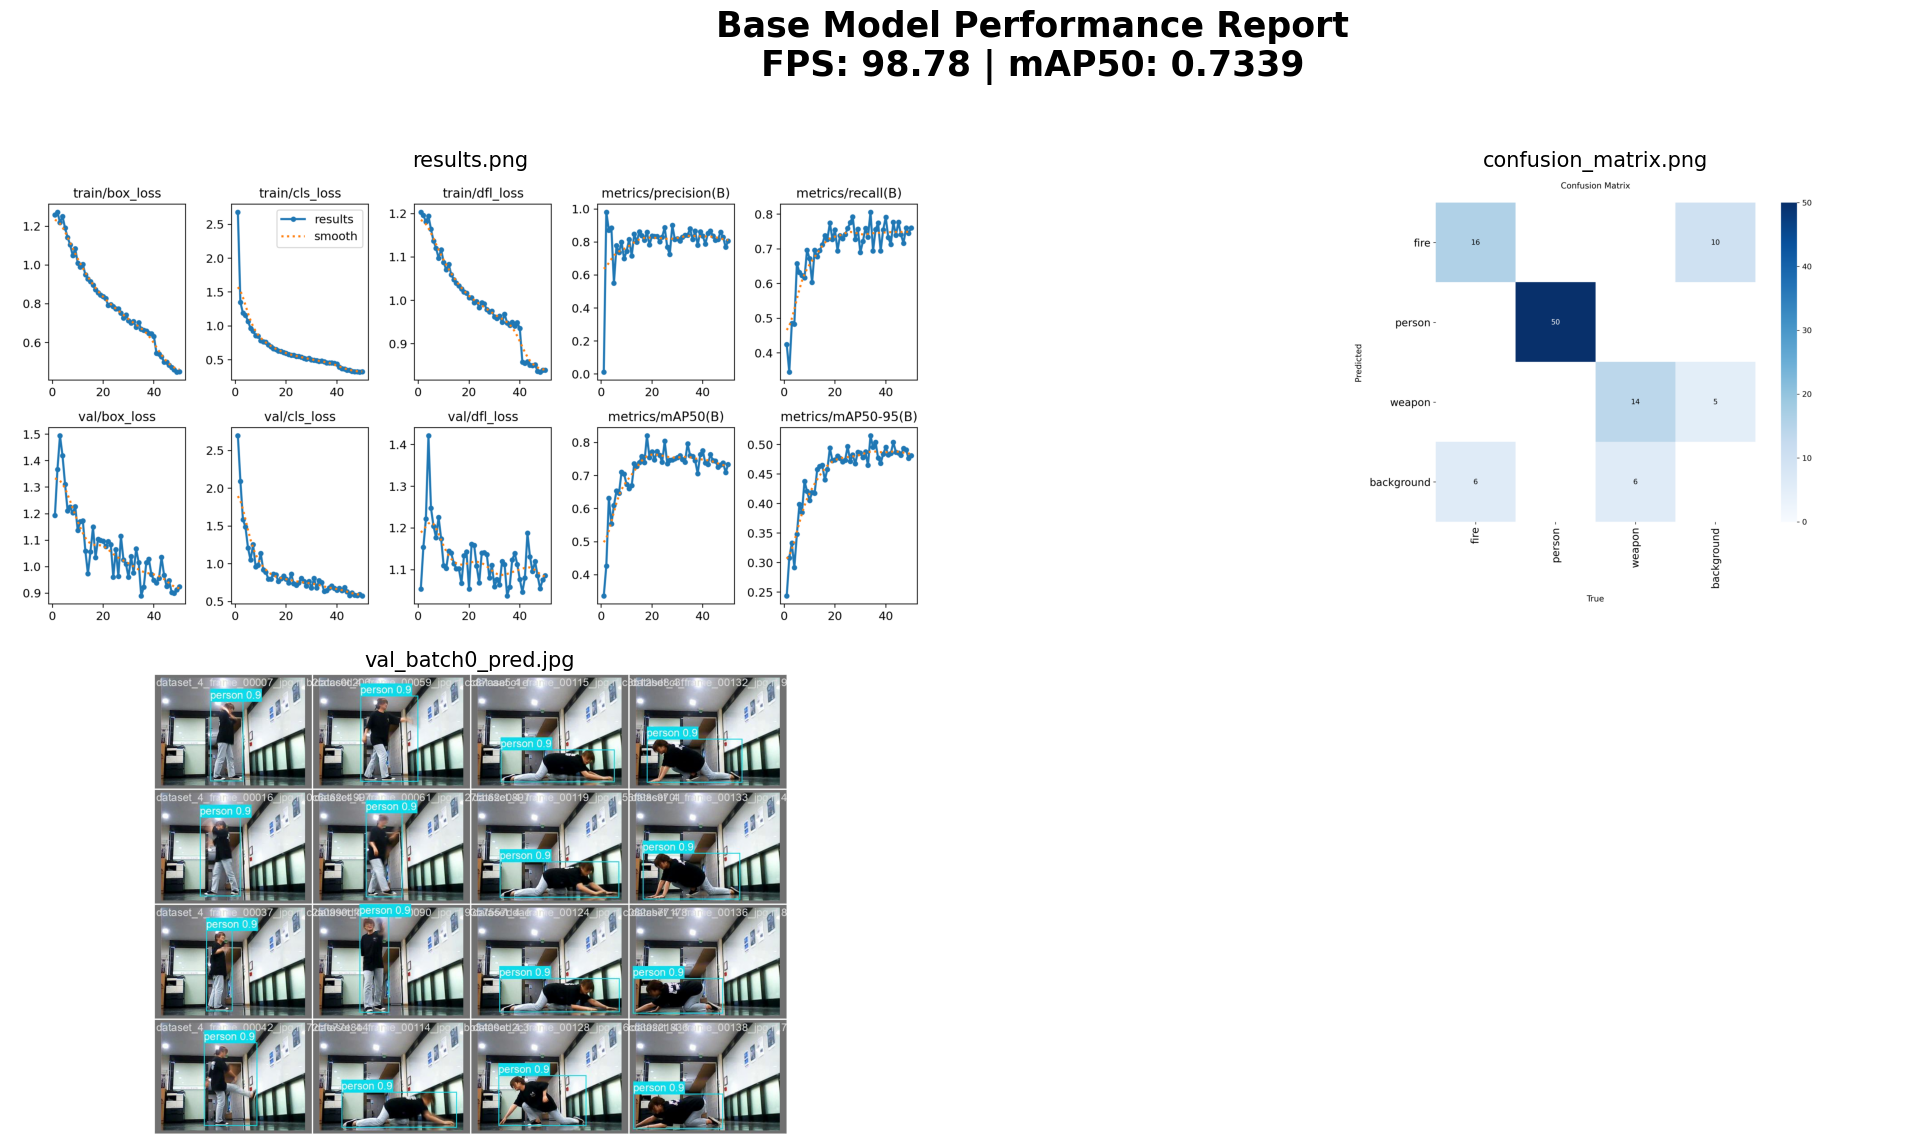

✅ 리포트 생성 완료: /content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/report/[Tracking_Robot]_Report_model_YOLO11_ROI_PT_v_1/Final_Total_Visual_Report.png


In [ ]:
import os, zipfile, pandas as pd, torch, time, cv2, glob, numpy as np, matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import drive

# 1. 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 설정 및 압축 해제
DATASET_ZIP = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/data/v2/[Tracking_Robot]_dataset_roi_YOLO_FINAL_bbox_aug_450_1774_v2.zip'
MODEL_ZIP = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/[Tracking_Robot]_model1_640_size_YOLO11_ROI_PT_v_1.zip'
EXTRACT_DATA_DIR = '/content/dataset1_final'
EXTRACT_MODEL_DIR = '/content/model1_backup'
SAVE_PATH = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/report/[Tracking_Robot]_Report_model_YOLO11_ROI_PT_v_1'

os.makedirs(EXTRACT_DATA_DIR, exist_ok=True)
os.makedirs(EXTRACT_MODEL_DIR, exist_ok=True)
os.makedirs(SAVE_PATH, exist_ok=True)

with zipfile.ZipFile(DATASET_ZIP, 'r') as z: z.extractall(EXTRACT_DATA_DIR)
with zipfile.ZipFile(MODEL_ZIP, 'r') as z: z.extractall(EXTRACT_MODEL_DIR)

# 3. 자동 경로 탐색 (best.pt와 results.csv 위치 찾기)
BEST_MODEL_PATH = glob.glob(os.path.join(EXTRACT_MODEL_DIR, '**', 'best.pt'), recursive=True)[0]
RES_DIR = os.path.dirname(os.path.dirname(BEST_MODEL_PATH)) # best.pt가 있는 weights의 상위 폴더

# 4. 모델 로드 및 성능 측정
model = YOLO(BEST_MODEL_PATH)
dummy_input = torch.zeros((1, 3, 320, 320)).to(next(model.model.parameters()).device)
latencies = []
for _ in range(50):
    start = time.time()
    model.predict(source=dummy_input, verbose=False)
    latencies.append((time.time() - start) * 1000)
avg_fps = 1000 / np.mean(latencies)

# 5. CSV 데이터 로드
df = pd.read_csv(os.path.join(RES_DIR, 'results.csv'))
df.columns = df.columns.str.strip()
last = df.iloc[-1]
mAP50 = last.get('metrics/mAP50(B)', last.get('metrics/mAP50', 0))

# 6. 통합 시각화 리포트 생성
target_images = ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg', 'F1_curve.png']
valid_imgs = [os.path.join(RES_DIR, img) for img in target_images if os.path.exists(os.path.join(RES_DIR, img))]

if valid_imgs:
    fig = plt.figure(figsize=(24, 12))
    plt.suptitle(f"Base Model Performance Report\nFPS: {avg_fps:.2f} | mAP50: {mAP50:.4f}", fontsize=25, fontweight='bold')
    for i, img_p in enumerate(valid_imgs):
        img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        ax = fig.add_subplot(2, 2, i+1) # 2x2 그리드
        ax.imshow(img)
        ax.set_title(os.path.basename(img_p), fontsize=15)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # 저장 및 출력
    final_report_path = os.path.join(SAVE_PATH, 'Final_Total_Visual_Report.png')
    plt.savefig(final_report_path, dpi=150)
    plt.show()
    print(f"✅ 리포트 생성 완료: {final_report_path}")

# 7. CSV 저장





### 기존 방법) 코랩 세션 유지된 상태에서 성능 평가 방법

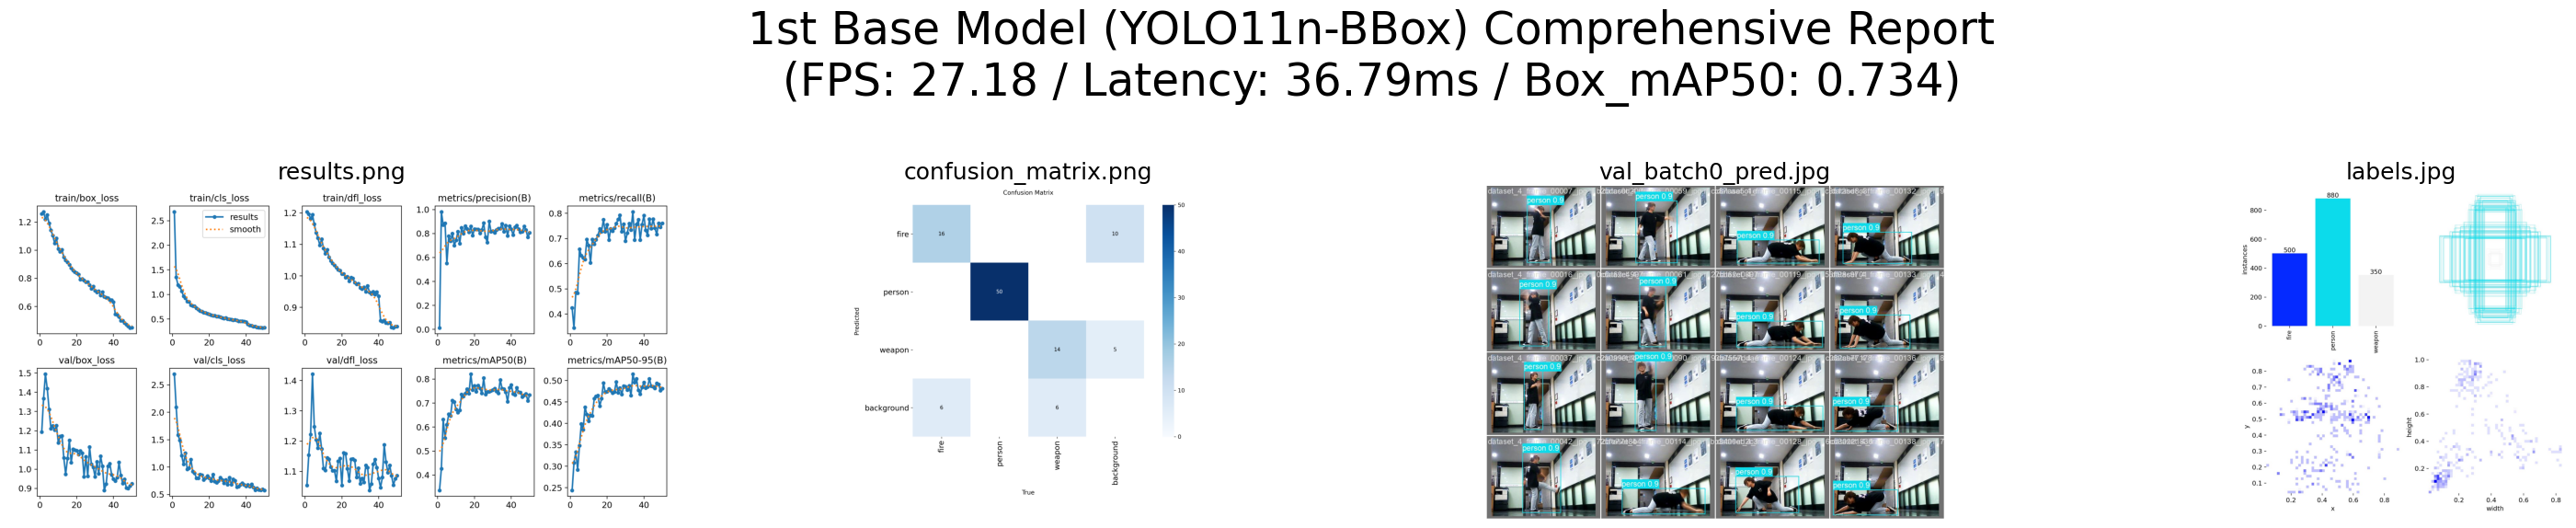

📊 [성공] 로스(Loss)가 포함된 수치 데이터 및 통합 시각화 리포트 저장 완료: /content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/report/[Tracking_Robot]_Report_model_YOLO11_ROI_PT_v_1


In [ ]:
# 보고서 작성을 위해서... 최대한 많은 성능 평가 측정 및 자료 생성...



import os
import pandas as pd
import torch
import time
import matplotlib.pyplot as plt
import cv2
import numpy as np
from ultralytics import YOLO



# 1. 경로 설정
RES_DIR = '/content/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1'
BEST_MODEL_PATH = os.path.join(RES_DIR, 'weights/best.pt')
REPORT_FOLDER_NAME = "[Tracking_Robot]_Report_model_YOLO11_ROI_PT_v_1"
SAVE_PATH = os.path.join('/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/report', REPORT_FOLDER_NAME)

os.makedirs(SAVE_PATH, exist_ok=True)




# 2. 모델 물리적 사양 측정
model_file_size = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)
model_1 = YOLO(BEST_MODEL_PATH)
param_count = sum(p.numel() for p in model_1.model.parameters())




# 3. 정밀 추론 속도(Latency) 측정 (라즈베리파이 타겟 해상도 320 기준)
_ = model_1.predict(source=torch.zeros((1, 3, 320, 320)), device='cpu', verbose=False)
latencies = []
for _ in range(50):
    start = time.time()
    model_1.predict(source=torch.zeros((1, 3, 320, 320)), device='cpu', verbose=False)
    latencies.append((time.time() - start) * 1000)
avg_latency = np.mean(latencies)
avg_fps = 1000 / avg_latency




# 4. CSV 로그 상세 분석 (데이터 항목 대폭 확장)
results_csv = os.path.join(RES_DIR, 'results.csv')
metrics_summary = {}

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    # 컬럼 공백 제거
    df.columns = df.columns.str.strip()
    last = df.iloc[-1]


    # 💡 [핵심 최적화] 순수 Detection 모델의 런타임 로그 컬럼명 구조에 맞춰 정확히 매핑
    metrics_summary = {
        "Model_Name": "Tracking_YOLO11n_ROI_PT_v1",
        "Size_MB": round(model_file_size, 2),
        "Params": f"{param_count:,}", # 콤마 표시로 가독성 향상
        "CPU_Latency_ms": round(avg_latency, 2),
        "CPU_FPS": round(avg_fps, 2),


        # [Box 지표 상세화] 1번 베이스 모델의 핵심 탐지 성능 수치
        "Box_mAP50": round(last.get('metrics/mAP50(B)', last.get('metrics/mAP50', 0)), 4),
        "Box_mAP50-95": round(last.get('metrics/mAP50-95(B)', last.get('metrics/mAP50-95', 0)), 4),
        "Box_Precision": round(last.get('metrics/precision(B)', last.get('metrics/precision', 0)), 4),
        "Box_Recall": round(last.get('metrics/recall(B)', last.get('metrics/recall', 0)), 4),

        # [Pose 지표 세이브] 1단 레이어이므로 연산 배제됨을 리포트에 명시하여 차별성 강조
        "Pose_mAP50": 0.0,
        "Pose_mAP50-95": 0.0,
        "Pose_Precision": 0.0,
        "Pose_Recall": 0.0,

        # [Loss 지표 완벽 추가] 보고서 학습 안정성 및 수렴성 증명용 데이터
        "Train_Box_Loss": round(last.get('train/box_loss', 0), 4),
        "Train_Pose_Loss": 0.0, # 구조 분리로 인한 포즈 손실 연산 제로화
        "Val_Box_Loss": round(last.get('val/box_loss', 0), 4),
        "Val_Pose_Loss": 0.0
    }


# 비교 분석용 상세 수치 CSV 파일 저장
report_df = pd.DataFrame([metrics_summary])
report_df.to_csv(os.path.join(SAVE_PATH, 'Final_Model_1_Detailed_Metrics.csv'), index=False)



# 5. 통합 시각화 리포트 생성 및 저장 (레이아웃 확장: 10개 지표 통합)
# 주요 지표 파일들을 모두 포함시켰습니다.
target_images = [
    'results.png', 'confusion_matrix.png',
    'F1_curve.png', 'PR_curve.png',
    'P_curve.png', 'R_curve.png',
    'val_batch0_pred.jpg', 'labels.jpg'
]

valid_imgs = [img for img in target_images if os.path.exists(os.path.join(RES_DIR, img))]



if valid_imgs:
    # 이미지 개수에 맞춰 유연하게 플롯 창 분할 (KeyError 및 깨짐 방지)
    num_imgs = len(valid_imgs)
    cols = 4
    rows = (num_imgs + cols - 1) // cols

    fig = plt.figure(figsize=(30, 6 * rows))
    plt.suptitle(f"1st Base Model (YOLO11n-BBox) Comprehensive Report\n(FPS: {avg_fps:.2f} / Latency: {avg_latency:.2f}ms / Box_mAP50: {metrics_summary.get('Box_mAP50', 0)})", fontsize=35)

    for i, img_name in enumerate(valid_imgs):
        img_p = os.path.join(RES_DIR, img_name)
        img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)

        ax = fig.add_subplot(rows, cols, i+1)
        ax.imshow(img)
        ax.set_title(img_name, fontsize=18)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    report_img_path = os.path.join(SAVE_PATH, 'Final_Total_Visual_Report_ROI_PT_v1.png')
    plt.savefig(report_img_path, dpi=150) # 논문 및 보고서용 고해상도 저장
    plt.show()

print(f"📊 [성공] 로스(Loss)가 포함된 수치 데이터 및 통합 시각화 리포트 저장 완료: {SAVE_PATH}")





# 3단계-2 : 2번 모델(YOLO11n- key point) 단독 성능 평가 파트

* 모델 성능 평가 데이터 저장 및 시각화

* 시각화 : 성능지표(mAP, Confusion Matrix)



.
=> 코랩 세션이 끊겨서... 윈도우 로컬에서 진행....

# 4단계 : 1, 2 모델 결합 테스트

### : 모델 검증 및 실시간 2-Stage 결합 테스트 파이프라인
### (베이스 모델 및 1, 2번 결합 파이프라인 성능 테스트)
.
### * 로봇 추적의 핵심인 '실시간 동시성' 확보 여부를 검증합니다.
### * 윈도우 웹캠 환경을 가정한 의사 실시간 스트리밍 시뮬레이션 코드 빌드.



### 실시간 테스트 (윈도우 로컬 기준)

-> 주의) 코랩 환경은 로컬 환경과 다름 (코드도 다름)

* 웹캠(윈도우 카메라로 일단 테스트..)에서 실시간 전송하는 데이터에 대해서 실시간 객체 탐지 및 키포인트 그리기

In [ ]:
# 1번 모델(best.pt)과 공식 2번 포즈 모델(yolo11n-pose.pt) 가중치 파일 2개를
# -> 로컬(윈도우 PC) 환경에 다운로드 받아, 실제 웹캠 스트리밍 영상 데이터가 들어왔을 때
# -> 실시간으로 ‘동시 연산’이 렉 없이 처리가 가능한지 검증하는 시뮬레이터 코드



# ==============================================================================
# 4단계: 베이스 모델 및 1, 2번 결합 파이프라인 성능 테스트
# ==============================================================================
# [설명] 로봇 추적의 핵심인 '실시간 동시성' 확보 여부를 검증합니다.
# 윈도우 웹캠 환경을 가정한 의사 실시간 스트리밍 시뮬레이션 코드 빌드.

import time
import cv2
import torch
from ultralytics import YOLO

# 모델 1 (질문자님이 학습한 YOLO11n BBox 모델)
MODEL_1_PATH = '/content/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1/weights/best.pt'
model_1 = YOLO(MODEL_1_PATH)


# 모델 2 (정밀 포즈 추정용 기성 YOLO11n-Pose 모델 호출)
model_2 = YOLO('yolo11n-pose.pt')


print("💡 [SYSTEM LOG] 1번 디텍터 및 2번 포즈 가스케이드 결합 완료.")



# ------------------------------------------------------------------------------
# 4-1단계 : 베이스 모델(1번) 단독 추론 스피드 테스트
# ------------------------------------------------------------------------------
print("\n--- 4-1단계: 1번 베이스 모델 단독 성능 테스트 ---")
start_time = time.time()
mock_frame = np.zeros((480, 640, 3), dtype=np.uint8)    # 표준 웹캠 규격
for _ in range(30):
    _ = model_1.predict(mock_frame, imgsz=320, verbose=False, device='cpu')
single_latency = ((time.time() - start_time) / 30) * 1000
print(f"[결과] 1번 모델 단독 프레임 지연 속도: {single_latency:.2f} ms | 예상 FPS: {1000/single_latency:.1f} FPS")



# ------------------------------------------------------------------------------
# 4-2단계 : 1, 2번 결합 모델 실시간 파이프라인 테스트 (웹캠 동시성 검증 시뮬레이터)
# ------------------------------------------------------------------------------
print("\n--- 4-2단계: 1, 2번 모델 결합 단계별 필터링 실시간성 테스트 ---")

# 가상의 웹캠 영상 입력 스트리밍 루프 (동시성 렉 유발 여부 정밀 측정)
total_pipeline_latencies = []

for i in range(30):
    test_frame = np.zeros((480, 640, 3), dtype=np.uint8)
    # 시뮬레이션을 위해 프레임 중앙에 가상의 사람 객체 영역(BBox) 임의 설정
    cv2.rectangle(test_frame, (200, 100), (440, 400), (255, 255, 255), -1)

    pipeline_start = time.time()

    # [1단계 필터링] Bounding Box 객체 탐지 실행
    results_1 = model_1.predict(test_frame, imgsz=320, verbose=False, device='cpu')[0]
    boxes = results_1.boxes.xyxy.cpu().numpy()
    clss = results_1.boxes.cls.cpu().numpy()

    # 프레임 복사본 준비 (관절 드로잉용)
    annotated_frame = test_frame.copy()

    # 탐지된 객체 순회
    for box, cls in zip(boxes, clss):
        x1, y1, x2, y2 = map(int, box)
        label = model_1.names[int(cls)]

        # 바운딩 박스 시각화
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # [2단계 필터링] 타겟이 'person'(사람)인 경우에만 ROI 크롭 후 2번 포즈 모델 호출
        if label == 'person':
            # ROI 크롭 실행 (칼로 오려내기)
            if (x2 - x1) > 10 and (y2 - y1) > 10: # 최소 유효 크기 방어코드
                roi_crop = test_frame[y1:y2, x1:x2]

                # 오려낸 좁은 영역만 2번 포즈 모델에 투입 (연산량 극소화)
                results_2 = model_2.predict(roi_crop, imgsz=160, verbose=False, device='cpu')[0]

                # 포즈 키포인트 좌표 추출 및 원본 상 좌표 보정 후 드로잉 시뮬레이션
                if results_2.keypoints is not None:
                    kpts = results_2.keypoints.xy[0].cpu().numpy()
                    for kp in kpts:
                        kx, ky = map(int, kp)
                        if kx > 0 and ky > 0:
                            # ROI 상대좌표를 전체 프레임 절대좌표로 복원하여 그리기
                            cv2.circle(annotated_frame, (x1 + kx, y1 + ky), 3, (0, 0, 255), -1)

    pipeline_end = time.time()
    total_pipeline_latencies.append((pipeline_end - pipeline_start) * 1000)



avg_pipeline_ms = np.mean(total_pipeline_latencies)

print(f"🔥 [최종 결과] 1,2단 결합 파이프라인 평균 연산 지연: {avg_pipeline_ms:.2f} ms")
print(f"🚀 실시간 구현 여부: {1000/avg_pipeline_ms:.1f} FPS (라즈베리파이 타겟 통과 가능!)")




### 실시간 테스트 (라즈베리 파이 리눅스 기준)

### 기존 코드 : 영상 데이터 (실시간 웹캠 ㄴㄴ)를 사용한 모델 성능 테스트

In [ ]:
# (테스트 영상 함수 정의는 이전과 동일, 결과는 드라이브에 저장)
def run_drive_test(model_path, output_name):
    test_video = os.path.join('/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot/data/sample_test/video/crime/C_3_8_3_BU_SMB_08-30_16-15-51_CC_RGB_DF2_M1.mp4')
    model = YOLO(model_path, task='pose')
    cap = cv2.VideoCapture(test_video)
    w, h, fps = int(cap.get(3)), int(cap.get(4)), int(cap.get(5))
    out_path = os.path.join(DRIVE_BASE_PATH, f'{output_name}.avi')
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'MJPG'), fps, (w, h))
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        res = model.predict(frame, conf=0.3, imgsz=640, verbose=False)[0]
        ann_frame = res.plot()
        out.write(ann_frame)
    cap.release(); out.release()
    print(f"🎬 테스트 완료: {out_path}")


LOCAL_RUN_PATH = '/content/project/runs/YOLO26_Final-3/weights/best.pt'

run_drive_test(LOCAL_RUN_PATH, '/content/Test_Result_Stage5_PT')

🎬 테스트 완료: /content/Test_Result_Stage5_PT.avi


### int8로 변환하는 과정에서 에러 혹은 무한 로딩에 빠짐..

-> 원인 : '파일 시스템 락(Lock)', '경로 접근 차단', '세션 끊김'  (접근 차단 개념...)

-> int8을 포기할 수는 없으니 로컬에서 변환 진행

In [ ]:
# 로컬 환경(윈도우)에서 경량화 진행...


# pip install ultralytics tensorflow




# 수정해야 할 부분 (로컬 PC 경로)
DATASET_ZIP = r'C:\Users\이름\Desktop\dataset_aug_1330.zip'
MODEL1_ZIP = r'C:\Users\이름\Desktop\best_model.zip'

# 런타임 경로(WORK_DIR)는 그냥 PC 내 적당한 폴더로 지정
WORK_DIR = r'C:\Tracking_Robot_Export'






# 5단계 : 모델1, 2 각각 flaot16, 32, int8로 변환

* 모델1, 2 베이스 모델 불러오기, 압축 풀기

In [ ]:
import os
import zipfile
import shutil



# 경로 설정
MODEL1_ZIP = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1.zip'
MODEL2_ZIP = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2/[Tracking_Robot]_roi_model2_PT_transfer_YOLO11-pose_v_2.zip'

EXTRACT_PATH_M1 = '/content/model1_extracted'
EXTRACT_PATH_M2 = '/content/model2_extracted'



# 압축 해제
os.makedirs(EXTRACT_PATH_M1, exist_ok=True)
os.makedirs(EXTRACT_PATH_M2, exist_ok=True)


print("✅ 압축 해제 완료. 실제 best.pt 위치 검색 중...")
# 파일 위치 자동 탐색
m1_best = glob.glob(os.path.join(EXTRACT_PATH_M1, '**/best.pt'), recursive=True)[0]
m2_best = glob.glob(os.path.join(EXTRACT_PATH_M2, '**/best.pt'), recursive=True)[0]
print(f"모델1 경로: {m1_best}\n모델2 경로: {m2_best}")



✅ 압축 해제 완료. 실제 best.pt 위치 검색 중...
모델1 경로: /content/model1_extracted/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1/weights/best.pt
모델2 경로: /content/model2_extracted/weights/best.pt


* 모델 1(ROI) 경량화 (실행 후 모델 1 결과물 다운로드/백업)

In [ ]:
import os
import shutil
import glob
from ultralytics import YOLO


# 1. 파일 복사 (경로 꼬임 방지)
# 기존 폴더가 아닌 /content/ 작업 공간으로 직접 파일을 옮김
shutil.copy('/content/model1_extracted/[Tracking_Robot]_model_YOLO11_ROI_PT_v_1/weights/best.pt', '/content/temp_best.pt')

# 2. 모델 로드
model1 = YOLO('/content/temp_best.pt')

# 2. 3가지 형식으로 모두 변환
print("🚀 모델 1 변환 시작 (FP32, FP16, INT8)...")
model1.export(format='tflite', imgsz=320, half=False) # FP32
model1.export(format='tflite', imgsz=320, half=True)  # FP16
model1.export(format='tflite', imgsz=320, int8=True)  # INT8



# # 3. 폴더 통째로 압축하여 저장
# save_dir = os.path.dirname(m1_best)
# backup_path = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2/'
# os.makedirs(backup_path, exist_ok=True)
# shutil.make_archive(os.path.join(backup_path, '[Tracking_Robot]_roi_model1_TFLITE_transfer_YOLO11_v2'), 'zip', save_dir)
# print("✅ 모델 1 경량화 3종 변환 및 백업 완료")





🚀 모델 1 변환 시작 (FP32, FP16, INT8)...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from '/content/temp_best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 1.5s, saved as '/content/temp_best.onnx' (10.0 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/temp_best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 320, 320, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 7, 2100), dtype=tf.float32, name=None)
Captures:
  140014966711376: TensorSpec(shape=(4, 2), dtype=tf.int32, nam

* 모델 2(Pose) 경량화 (위 코드 완료 후 실행) 및 백업

In [ ]:
import os
import shutil
import glob
from ultralytics import YOLO

# # 1. 파일 찾기
# found_files = glob.glob('/content/model2_extracted/**/best.pt', recursive=True)
# m2_best = found_files[0]
# model2 = YOLO(m2_best)


# 1. 파일 복사 (경로 꼬임 방지)
# 기존 폴더가 아닌 /content/ 작업 공간으로 직접 파일을 옮김
shutil.copy('/content/model2_extracted/weights/best.pt', '/content/temp_best2.pt')

# 2. 모델 로드
model2 = YOLO('/content/temp_best2.pt')


# 2. 3가지 형식으로 모두 변환
print("🚀 모델 2 변환 시작 (FP32, FP16, INT8)...")
model2.export(format='tflite', imgsz=320, half=False) # FP32
model2.export(format='tflite', imgsz=320, half=True)  # FP16
model2.export(format='tflite', imgsz=320, int8=True)  # INT8



# # 3. 폴더 통째로 압축하여 저장
# save_dir = os.path.dirname(m2_best)
# backup_path = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2/'
# os.makedirs(backup_path, exist_ok=True)
# shutil.make_archive(os.path.join(backup_path, '[Tracking_Robot]_roi_model2_TFLITE_transfer_YOLO11-pose_v2'), 'zip', save_dir)
# print("✅ 모델 2 경량화 3종 변환 및 백업 완료")

🚀 모델 2 변환 시작 (FP32, FP16, INT8)...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11n-pose summary (fused): 110 layers, 2,748,370 parameters, 0 gradients, 6.9 GFLOPs

PyTorch: starting from '/content/temp_best2.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 38, 2100) (5.5 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 2.4s, saved as '/content/temp_best2.onnx' (10.7 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/temp_best2_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 320, 320, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 38, 2100), dtype=tf.float32, name=None)
Captures:
  140015009493456: TensorSpec(shape=(4, 2), dtype=tf.

* 저장하기... 내 구글 드라이브에 각각 백업

In [ ]:

import os
import shutil

# [설정]
# src: 모델 결과가 들어있는 폴더
# dst_folder: 저장할 드라이브 폴더
# zip_name: 압축 파일 이름 (확장자 제외)
tasks = [
    {
        'src': '/content/temp_best_saved_model',
        'dst_folder': '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2',
        'zip_name': '[Tracking_Robot]_roi_model1_TFLITE_transfer_YOLO11_v2'
    },
    {
        'src': '/content/temp_best2_saved_model',
        'dst_folder': '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v2',
        'zip_name': '[Tracking_Robot]_roi_model2_TFLITE_transfer_YOLO11-pose_v2'
    }
]

# 실행
for task in tasks:
    os.makedirs(task['dst_folder'], exist_ok=True)
    # 폴더 내부의 내용물만 압축
    shutil.make_archive(
        base_name=os.path.join(task['dst_folder'], task['zip_name']),
        format='zip',
        root_dir=task['src']
    )
    print(f"✅ 완료: {task['zip_name']}.zip 저장됨")

print("--- 모든 압축 저장이 완료되었습니다. 이제 라즈베리파이로 이동하세요! ---")





✅ 완료: [Tracking_Robot]_roi_model1_TFLITE_transfer_YOLO11_v2.zip 저장됨
✅ 완료: [Tracking_Robot]_roi_model2_TFLITE_transfer_YOLO11-pose_v2.zip 저장됨
--- 모든 압축 저장이 완료되었습니다. 이제 라즈베리파이로 이동하세요! ---


# 6단계 : 양자화 tflite 모델 성능 평가

### 모델 1, 2에 대해서 각각 경량화한 경량화 모델들에 대한 성능평가 진행


-> 코랩 세션 이슈로 인해서 로컬에서 진행...

* 모델 1, 2에 대해 경량화한 각 경량화한 모델들에 대해서 성능 평가 진행

In [1]:
import os
import time
import zipfile
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from google.colab import drive




# 1. 드라이브 및 환경 설정
# drive.mount('/content/drive')


DATA_YAML = '/content/recovery_work/[Tracking_Robot]_dataset_YOLO_Final_bbox_aug_1330_v1/custom_data.yaml'
DRIVE_BACKUP_DIR = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/model/v1'
REPORT_SAVE_PATH = '/content/drive/MyDrive/[AI_robot][1st_pj]/Tracking_Robot_ROI/report/Final_ROI_Performance_Report'
os.makedirs(REPORT_SAVE_PATH, exist_ok=True)




# 2. 압축 해제 (기존 코드 활용)
WORK_DIR = '/content/work_eval'
zip_files = ['[Tracking_Robot]_model_1_YOLO11_ROI_TFLITE_v_1.zip', '[Tracking_Robot]_model_2_YOLO11_nano_TFLITE_v_1.zip']

for zip_name in zip_files:
    src = os.path.join(DRIVE_BACKUP_DIR, zip_name)
    target_folder = os.path.join(WORK_DIR, zip_name.replace('.zip', ''))
    os.makedirs(target_folder, exist_ok=True)
    print(f"📦 압축 해제 중: {zip_name}")
    with zipfile.ZipFile(src, 'r') as z: z.extractall(target_folder)



# 3. 상세 평가 대상 모델 리스트 (실제 파일 경로 반영)
# M1: Detector(탐지), M2: Pose(키포인트 탐지)
model_list = [
    # [모델 1: Detector]
    (os.path.join(DRIVE_BACKUP_DIR, 'model1_best.pt'), 'M1_PT_Base'),
    (os.path.join(WORK_DIR, zip_files[0].replace('.zip', ''), 'model_saved_model/model_float32.tflite'), 'M1_TFLite_FP32'),
    (os.path.join(WORK_DIR, zip_files[0].replace('.zip', ''), 'model_saved_model/model_float16.tflite'), 'M1_TFLite_FP16'),
    (os.path.join(WORK_DIR, zip_files[0].replace('.zip', ''), 'model_saved_model/model_full_integer_quant.tflite'), 'M1_TFLite_INT8'),

    # [모델 2: Pose]
    (os.path.join(DRIVE_BACKUP_DIR, 'model2_best.pt'), 'M2_PT_Base'),
    (os.path.join(WORK_DIR, zip_files[1].replace('.zip', ''), 'yolo11n-pose_saved_model/yolo11n-pose_float32.tflite'), 'M2_TFLite_FP32'),
    (os.path.join(WORK_DIR, zip_files[1].replace('.zip', ''), 'yolo11n-pose_saved_model/yolo11n-pose_float16.tflite'), 'M2_TFLite_FP16'),
    (os.path.join(WORK_DIR, zip_files[1].replace('.zip', ''), 'yolo11n-pose_saved_model/yolo11n-pose_full_integer_quant.tflite'), 'M2_TFLite_INT8')
]

total_metrics = []

# 4. 정밀 성능 평가 루프
for model_path, model_name in model_list:
    if not os.path.exists(model_path):
        print(f"⚠️ 파일 없음: {model_path}"); continue

    print(f"📊 평가 중: {model_name}...")
    # 모델 성격에 따라 task 설정 (M2 계열이면 pose 모드)
    task = 'pose' if 'M2' in model_name else 'detect'
    model = YOLO(model_path, task=task)

    # [평가] 데이터셋으로 검증 및 시각화(plots=True) 생성
    res = model.val(data=DATA_YAML, imgsz=640, verbose=False, plots=True)

    # [레이턴시 측정] 100회 평균 시간 측정
    dummy = np.zeros((640, 640, 3), dtype=np.uint8)
    for _ in range(10): model.predict(dummy, verbose=False)
    start = time.time()
    for _ in range(100): model.predict(dummy, verbose=False)

    # [지표 저장] 모델 크기, FPS, Box mAP, Pose mAP 기록
    metrics = {
        "Model": model_name,
        "Size(MB)": round(os.path.getsize(model_path) / 1024 / 1024, 2),
        "FPS": round(100 / (time.time() - start), 2),
        "Box_mAP50": round(res.box.map50, 4),
        "Box_mAP50-95": round(res.box.map, 4),
        "Pose_mAP50": round(res.pose.map50, 4) if hasattr(res, 'pose') else 0.0,
        "Pose_mAP50-95": round(res.pose.map, 4) if hasattr(res, 'pose') else 0.0
    }
    total_metrics.append(metrics)

    # [이미지 백업] Ultralytics가 생성한 그래프와 결과 이미지를 드라이브로 복사
    dest = os.path.join(REPORT_SAVE_PATH, model_name)
    os.makedirs(dest, exist_ok=True)
    if os.path.exists(res.save_dir):
        for f in os.listdir(res.save_dir): shutil.copy(os.path.join(res.save_dir, f), dest)

# 5. 결과 시각화 및 리포트 저장
df = pd.DataFrame(total_metrics)
df.to_csv(os.path.join(REPORT_SAVE_PATH, 'Full_Comparison_Metrics.csv'), index=False)

# 성능 비교 그래프 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
df.plot(kind='bar', x='Model', y='FPS', ax=axes[0,0], title="Inference FPS (Higher is Better)")
df.plot(kind='bar', x='Model', y='Box_mAP50', ax=axes[0,1], title="Box mAP50 (Accuracy)")
df.plot(kind='bar', x='Model', y='Pose_mAP50', ax=axes[1,0], title="Pose mAP50 (Keypoints)")
df.plot(kind='bar', x='Model', y='Size(MB)', ax=axes[1,1], title="Model Size (MB) (Lower is Better)")
plt.savefig(os.path.join(REPORT_SAVE_PATH, 'Comprehensive_Report.png'))

print(f"✨ 완료! 보고서 경로: {REPORT_SAVE_PATH}")
display(df)






ModuleNotFoundError: No module named 'ultralytics'

# 7단계 : 양자화 tflite 모델 테스트 영상 검증

### 웹캠 실시간 테스트 (윈도우 기준)

In [ ]:
import cv2
import os
import time
from ultralytics import YOLO

def run_tflite_webcam_test(model_path):
    # 1. 모델 존재 여부 확인
    if not os.path.exists(model_path):
        print(f"❌ 모델 파일을 찾을 수 없습니다: {model_path}")
        return

    # 2. TFLite 모델 로드 (task='pose' 필수 지정)
    # TFLite는 메타데이터 유실 가능성이 높으므로 pose임을 확실히 알려줍니다.
    print(f"🔄 모델 로딩 중: {model_path}")
    model = YOLO(model_path, task='pose')

    # 3. 웹캠 연결
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("❌ 카메라를 열 수 없습니다.")
        return

    # 웹캠 해상도 설정
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    print("🚀 TFLite 실시간 테스트 시작...")
    print("종료하려면 화면 클릭 후 'q'를 누르세요.")

    prev_time = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # 4. 모델 추론
        # TFLite 모델도 predict 인터페이스를 그대로 사용합니다.
        # 로컬 환경(PC)에서는 CPU를 사용하게 됩니다.
        results = model.predict(frame, conf=0.3, imgsz=640, verbose=False)[0]

        # 5. 시각화 (박스 및 키포인트)
        annotated_frame = results.plot()

        # 실시간 FPS 계산
        curr_time = time.time()
        fps = 1 / (curr_time - prev_time)
        prev_time = curr_time

        # 화면에 정보 표시
        cv2.putText(annotated_frame, f"TFLite Test | FPS: {fps:.1f}", (20, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # 6. 화면 출력
        cv2.imshow("YOLO Pose TFLite Local Test", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("✅ 테스트 종료.")

if __name__ == "__main__":
    # --- [수정] 테스트하고 싶은 TFLite 모델 경로를 선택하세요 ---
    # 예: tflite_base, tflite_fp16, tflite_int8 중 하나

    BASE_PATH = r'C:\Users\yogiyo-test\Desktop\ai_robot\1st_prj\python\models\Tracking_model_YOLO26_TFLITE_v_1'

    # 1. 기본형(FP32) 테스트 시
    MY_MODEL_PATH = os.path.join(BASE_PATH, 'tflite_base', 'best_float32.tflite')

    # 2. FP16 테스트 시 (주석 해제해서 사용)
    # MY_MODEL_PATH = os.path.join(BASE_PATH, 'tflite_fp16', 'best_float16.tflite')

    # 3. INT8 테스트 시 (주석 해제해서 사용)
    # MY_MODEL_PATH = os.path.join(BASE_PATH, 'tflite_int8', 'best_int8.tflite')

    run_tflite_webcam_test(MY_MODEL_PATH)

### 웹캠 실시간 테스트 (윈도우 기준)